In [624]:
import pandas as pd

df = pd.read_csv("all-weeks-global.csv")
df.head()



,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,cumulative_weeks_in_top_10
0,2022-01-16,Films (English),1,Brazen,NaN,45340000,1
1,2022-01-16,Films (English),2,Don't Look Up,NaN,28390000,4
2,2022-01-16,Films (English),3,Mother/Android,NaN,23170000,2
3,2022-01-16,Films (English),4,The Secret Life of Pets 2,NaN,9390000,1
4,2022-01-16,Films (English),5,Just Go With It,NaN,8790000,3


In [625]:
content = (
    df.groupby(
        ["category", "show_title", "season_title"],
        dropna=False
    )
    .agg(
        top10_weeks=("cumulative_weeks_in_top_10", "max")
    )
    .reset_index()
)

content["type"] = content["category"].apply(
    lambda x: "TV" if x.startswith("TV") else "Film"
)

summary = (
    content.groupby("type")["top10_weeks"]
    .agg(["count", "mean", "median", "max"])
    .round(2)
)

summary

,count,mean,median,max
type,,,,
Film,260,2.23,2.0,10
TV,179,3.24,2.0,18


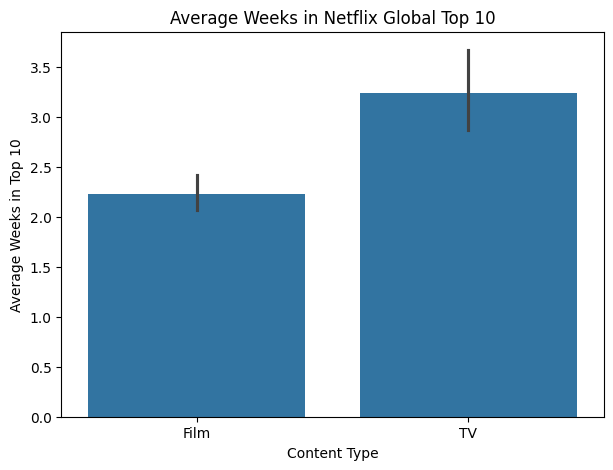

In [626]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.barplot(
    data=content,
    x="type",
    y="top10_weeks"
)

plt.title("Average Weeks in Netflix Global Top 10")
plt.xlabel("Content Type")
plt.ylabel("Average Weeks in Top 10")

plt.show()

## EDA 1. 영화와 TV의 TOP10 유지 기간 비교

넷플릭스 글로벌 TOP10 데이터를 분석한 결과, 영화의 평균 TOP10 유지 기간은 약 2.23주, TV 콘텐츠는 약 3.24주로 나타났다.

TV 콘텐츠가 영화보다 평균 약 1주 더 오래 TOP10을 유지했다.

이는 TV 콘텐츠가 영화보다 장기 흥행에 유리한 경향이 있음을 보여준다. 다만 콘텐츠 유형이 장기 흥행의 직접적인 원인이라고 단정할 수는 없다.

In [627]:
# week 컬럼을 날짜 형식으로 변환
df["week"] = pd.to_datetime(df["week"])

# 콘텐츠별 첫 등장 데이터
first_entry = (
    df.sort_values("week")
      .groupby(
          ["category", "show_title", "season_title"],
          dropna=False
      )
      .first()
      .reset_index()
)

# 콘텐츠별 최종 TOP10 유지 주수
max_weeks = (
    df.groupby(
        ["category", "show_title", "season_title"],
        dropna=False
    )["cumulative_weeks_in_top_10"]
    .max()
    .reset_index(name="top10_weeks")
)

# 첫 진입 정보 + 최종 유지 기간 합치기
entry_analysis = first_entry.merge(
    max_weeks,
    on=["category", "show_title", "season_title"]
)

entry_analysis[
    ["show_title", "weekly_rank", "top10_weeks"]
].head()

,show_title,weekly_rank,top10_weeks
0,14 Peaks: Nothing Is Impossible,7,1
1,21 Jump Street,6,1
2,211,6,1
3,6 Underground,9,1
4,A Boy Called Christmas,3,5


In [628]:
corr = entry_analysis["weekly_rank"].corr(
    entry_analysis["top10_weeks"]
)

print("상관계수:", round(corr, 2))

상관계수: -0.38


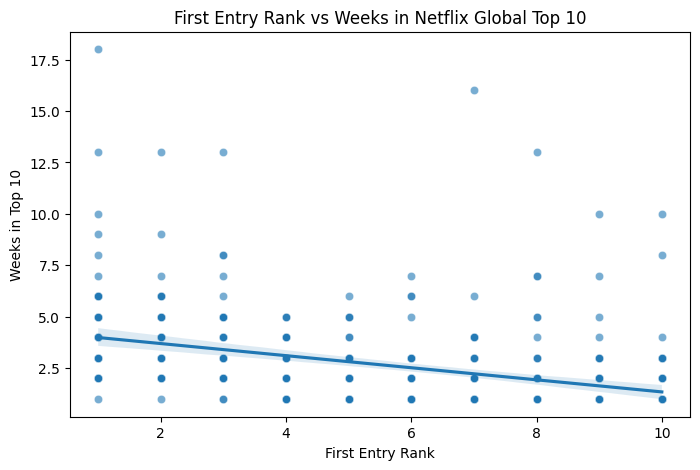

In [629]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=entry_analysis,
    x="weekly_rank",
    y="top10_weeks",
    alpha=0.6
)

sns.regplot(
    data=entry_analysis,
    x="weekly_rank",
    y="top10_weeks",
    scatter=False
)

plt.title("First Entry Rank vs Weeks in Netflix Global Top 10")
plt.xlabel("First Entry Rank")
plt.ylabel("Weeks in Top 10")

plt.show()

##EDA 2. 첫 진입 순위와 TOP10 유지 기간의 관계

첫 TOP10 진입 순위와 최종 TOP10 유지 기간의 상관계수는 약 -0.38로 나타났다.

넷플릭스 순위는 숫자가 작을수록 높은 순위를 의미하므로, 초기 진입 순위가 높은 콘텐츠일수록 장기간 TOP10을 유지하는 경향이 있음을 확인할 수 있다.

다만 산점도에서 개별 콘텐츠의 편차가 크게 나타났으며, 초기 진입 순위만으로 장기 흥행 여부를 완전히 설명하기는 어렵다. 따라서 시청시간, 콘텐츠 유형, 국가별 확산 정도 등 다른 요인을 함께 살펴볼 필요가 있다.

In [630]:
# 첫 진입 시청시간과 최종 TOP10 유지 기간만 추출
view_analysis = entry_analysis[
    ["show_title", "weekly_hours_viewed", "top10_weeks"]
].copy()

view_analysis.head()

,show_title,weekly_hours_viewed,top10_weeks
0,14 Peaks: Nothing Is Impossible,12170000,1
1,21 Jump Street,11690000,1
2,211,7900000,1
3,6 Underground,7770000,1
4,A Boy Called Christmas,26820000,5


In [631]:
corr_view = view_analysis["weekly_hours_viewed"].corr(
    view_analysis["top10_weeks"]
)

print("상관계수:", round(corr_view, 2))

상관계수: 0.46


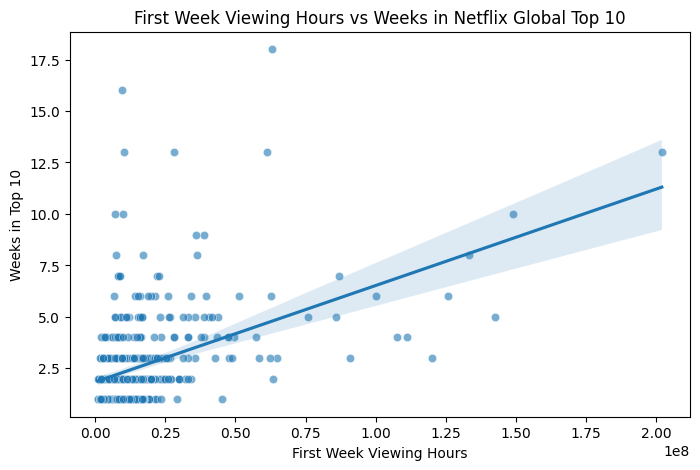

In [632]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=view_analysis,
    x="weekly_hours_viewed",
    y="top10_weeks",
    alpha=0.6
)

sns.regplot(
    data=view_analysis,
    x="weekly_hours_viewed",
    y="top10_weeks",
    scatter=False
)

plt.title("First Week Viewing Hours vs Weeks in Netflix Global Top 10")
plt.xlabel("First Week Viewing Hours")
plt.ylabel("Weeks in Top 10")

plt.show()

##EDA 3. 첫 주 시청시간과 TOP10 유지 기간의 관계

첫 주 시청시간과 최종 TOP10 유지 기간의 상관계수는 약 0.46으로 나타났다.

이는 공개 초기에 많은 시청시간을 확보한 콘텐츠일수록 장기간 TOP10을 유지하는 경향이 있음을 보여준다.

다만 모든 고시청 콘텐츠가 장기 흥행으로 이어지는 것은 아니며, 콘텐츠 유형이나 국가별 확산 정도 같은 다른 요인도 함께 고려할 필요가 있다.

In [633]:
countries_df = pd.read_csv(
    "all-weeks-countries.csv",
    encoding="latin1"
)

countries_df.head()

,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10
0,Argentina,AR,2022-01-16,Films,1,Brazen,NaN,1
1,Argentina,AR,2022-01-16,Films,2,Mother/Android,NaN,2
2,Argentina,AR,2022-01-16,Films,3,The Clovehitch Killer,NaN,1
3,Argentina,AR,2022-01-16,Films,4,The Secret Life of Pets 2,NaN,1
4,Argentina,AR,2022-01-16,Films,5,Don't Look Up,NaN,4


In [634]:
country_reach = (
    countries_df.groupby(
        ["show_title", "season_title"],
        dropna=False
    )["country_name"]
    .nunique()
    .reset_index(name="country_count")
)

country_reach.head()

,show_title,season_title,country_count
0,'76,NaN,1
1,10 Cloverfield Lane,NaN,3
2,1000 Miles from Christmas,NaN,15
3,12 Strong,NaN,4
4,13 Going on 30,NaN,6


In [635]:
global_weeks = (
    df.groupby(
        ["show_title", "season_title"],
        dropna=False
    )["cumulative_weeks_in_top_10"]
    .max()
    .reset_index(name="top10_weeks")
)

reach_analysis = global_weeks.merge(
    country_reach,
    on=["show_title", "season_title"],
    how="inner"
)

reach_analysis.head()

,show_title,season_title,top10_weeks,country_count
0,1000 Miles from Christmas,NaN,2,15
1,14 Peaks: Nothing Is Impossible,NaN,1,45
2,21 Jump Street,NaN,1,1
3,211,NaN,1,23
4,6 Underground,NaN,1,12


In [636]:
corr_country = reach_analysis["country_count"].corr(
    reach_analysis["top10_weeks"]
)

print("상관계수:", round(corr_country, 2))

상관계수: 0.43


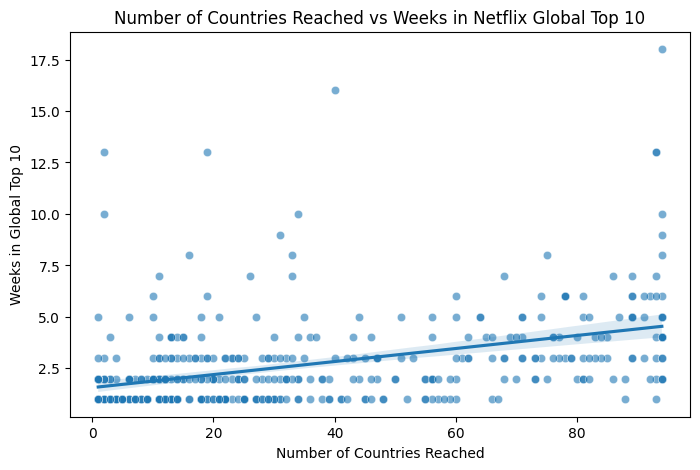

In [637]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=reach_analysis,
    x="country_count",
    y="top10_weeks",
    alpha=0.6
)

sns.regplot(
    data=reach_analysis,
    x="country_count",
    y="top10_weeks",
    scatter=False
)

plt.title("Number of Countries Reached vs Weeks in Netflix Global Top 10")
plt.xlabel("Number of Countries Reached")
plt.ylabel("Weeks in Global Top 10")

plt.show()

##EDA 4. 국가별 확산 범위와 글로벌 TOP10 유지 기간의 관계

콘텐츠가 TOP10에 진입한 국가 수와 글로벌 TOP10 유지 기간의 상관계수는 약 0.43으로 나타났다.

이는 여러 국가에서 동시에 인기를 얻은 콘텐츠일수록 글로벌 TOP10에도 장기간 머무르는 경향이 있음을 보여준다.

다만 일부 콘텐츠는 적은 국가에서 인기를 얻었음에도 장기간 글로벌 TOP10을 유지했고, 많은 국가에 진입했지만 비교적 짧게 흥행한 콘텐츠도 존재했다. 따라서 국가별 확산 범위만으로 장기 흥행 여부를 설명하기에는 한계가 있다.

In [638]:
top_long_running = (
    content.sort_values(
        "top10_weeks",
        ascending=False
    )
    .head(15)
    [
        [
            "show_title",
            "season_title",
            "category",
            "top10_weeks"
        ]
    ]
)

top_long_running

,show_title,season_title,category,top10_weeks
419,Squid Game,Squid Game: Season 1,TV (Non-English),18
386,Hometown Cha-Cha-Cha,Hometown Cha-Cha-Cha: Season 1,TV (Non-English),16
307,Maid,Maid: Limited Series,TV (English),13
406,Money Heist,Money Heist: Part 5,TV (Non-English),13
409,"Newly Rich, Newly Poor","Newly Rich, Newly Poor: Season 1",TV (Non-English),13
367,Carinha de Anjo,Carinha de Anjo: Season 1,TV (Non-English),13
368,Carrossel,NaN,TV (Non-English),10
425,The King's Affection,The King's Affection: Season 1,TV (Non-English),10
71,Red Notice,NaN,Films (English),10
427,The Queen of Flow,The Queen of Flow: Season 2,TV (Non-English),9


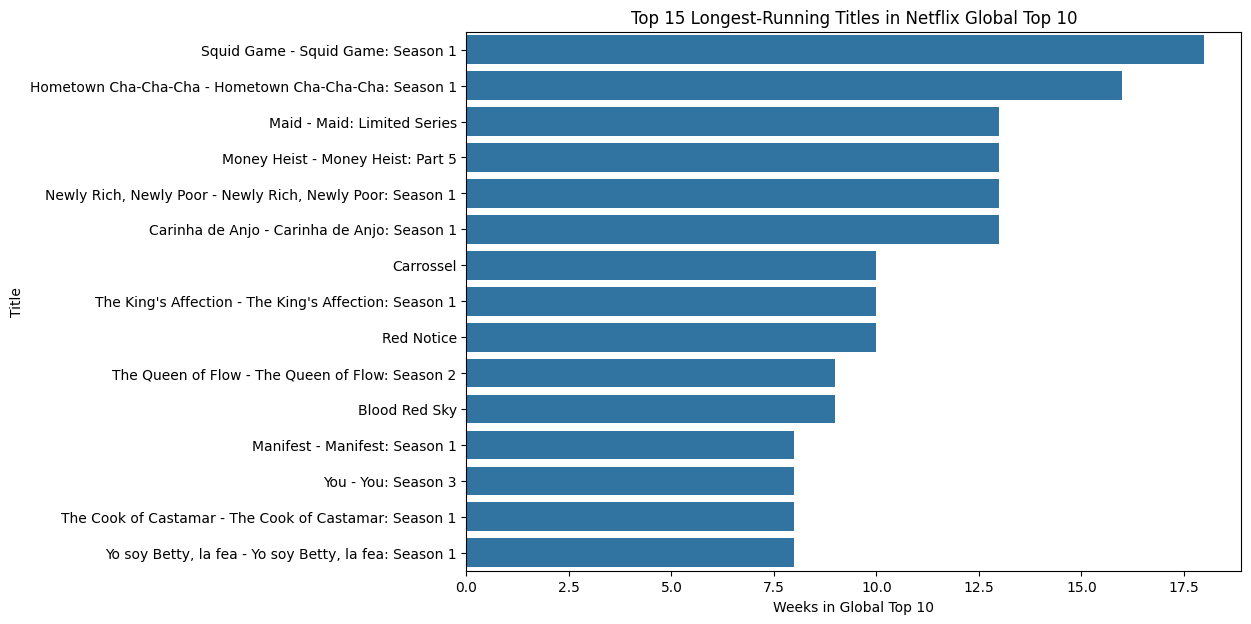

In [639]:
top15 = top_long_running.copy()

# 시즌명이 있으면 작품명 + 시즌명으로 표시
top15["label"] = top15.apply(
    lambda row:
        f"{row['show_title']} - {row['season_title']}"
        if pd.notna(row["season_title"])
        else row["show_title"],
    axis=1
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top15,
    x="top10_weeks",
    y="label"
)

plt.title("Top 15 Longest-Running Titles in Netflix Global Top 10")
plt.xlabel("Weeks in Global Top 10")
plt.ylabel("Title")

plt.show()

##EDA 5. 장기 흥행 콘텐츠 TOP15

글로벌 TOP10 유지 기간이 긴 콘텐츠를 확인한 결과, Squid Game 시즌 1이 18주로 가장 오래 TOP10을 유지했고 Hometown Cha-Cha-Cha 시즌 1이 16주로 뒤를 이었다.

상위권에는 영화보다 TV 콘텐츠가 많이 포함되어 있었으며, 특히 비영어권 TV 콘텐츠가 눈에 띄었다.

이는 앞선 EDA에서 확인한 TV 콘텐츠의 장기 흥행 경향과 비영어권 TV 콘텐츠의 높은 유지력을 실제 작품 사례에서도 확인할 수 있음을 보여준다.

다만 이번 데이터는 약 29주 기간만 포함하고 있어, 데이터 종료 이후에도 흥행이 이어진 작품의 실제 최종 유지 기간은 더 길 수 있다.

# EDA 종합 요약

넷플릭스 글로벌 TOP10 데이터를 분석한 결과, 장기 흥행과 관련된 몇 가지 패턴을 확인할 수 있었다.

## 1. TV 콘텐츠는 영화보다 평균적으로 더 오래 TOP10을 유지했다.
- 영화 평균 유지 기간: 약 2.23주
- TV 평균 유지 기간: 약 3.24주

## 2. 첫 TOP10 진입 순위가 높을수록 장기 흥행하는 경향이 있었다.
- 상관계수: 약 -0.38
- 다만 초기 순위만으로 장기 흥행을 충분히 설명하기에는 한계가 있었다.

## 3. 첫 주 시청시간이 높을수록 장기간 TOP10을 유지하는 경향이 있었다.
- 상관계수: 약 0.46

## 4. 많은 국가의 TOP10에 진입한 콘텐츠일수록 글로벌 TOP10에도 오래 머무르는 경향이 있었다.
- 상관계수: 약 0.43

## 5. 실제 장기 흥행작에서는 TV 및 비영어권 TV 콘텐츠가 상위권에 많이 나타났다.
- Squid Game 시즌 1: 18주
- Hometown Cha-Cha-Cha 시즌 1: 16주

In [640]:
# 글로벌 데이터에서 콘텐츠별 첫 등장 주 확인
first_week_info = (
    df.sort_values("week")
      .groupby(
          ["show_title", "season_title"],
          dropna=False
      )["week"]
      .first()
      .reset_index(name="first_week")
)

# 국가별 데이터 week도 날짜 형식으로 변환
countries_df["week"] = pd.to_datetime(countries_df["week"])

# 작품별 첫 등장 주 정보 결합
first_week_country_data = countries_df.merge(
    first_week_info,
    on=["show_title", "season_title"],
    how="inner"
)

# 글로벌 첫 등장 주와 같은 주의 국가 데이터만 사용
first_week_country_data = first_week_country_data[
    first_week_country_data["week"]
    == first_week_country_data["first_week"]
]

# 첫 주에 진입한 국가 수 계산
first_week_reach = (
    first_week_country_data.groupby(
        ["show_title", "season_title"],
        dropna=False
    )["country_name"]
    .nunique()
    .reset_index(name="first_week_country_count")
)

first_week_reach.head()

,show_title,season_title,first_week_country_count
0,1000 Miles from Christmas,NaN,12
1,14 Peaks: Nothing Is Impossible,NaN,45
2,21 Jump Street,NaN,1
3,211,NaN,21
4,6 Underground,NaN,12


In [641]:
model_df_clean = entry_analysis[
    [
        "show_title",
        "season_title",
        "category",
        "weekly_rank",
        "weekly_hours_viewed",
        "top10_weeks"
    ]
].copy()

model_df_clean = model_df_clean.merge(
    first_week_reach,
    on=["show_title", "season_title"],
    how="left"
)

# 첫 주 국가 데이터가 없는 경우 0 처리
model_df_clean["first_week_country_count"] = (
    model_df_clean["first_week_country_count"]
    .fillna(0)
)

# 4주 이상이면 장기 흥행
model_df_clean["long_hit"] = (
    model_df_clean["top10_weeks"] >= 4
).astype(int)

model_df_clean.head()

,show_title,season_title,category,weekly_rank,weekly_hours_viewed,top10_weeks,first_week_country_count,long_hit
0,14 Peaks: Nothing Is Impossible,NaN,Films (English),7,12170000,1,45.0,0
1,21 Jump Street,NaN,Films (English),6,11690000,1,1.0,0
2,211,NaN,Films (English),6,7900000,1,21.0,0
3,6 Underground,NaN,Films (English),9,7770000,1,12.0,0
4,A Boy Called Christmas,NaN,Films (English),3,26820000,5,70.0,1


In [642]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# 1. 사용할 변수
X_clean = model_df_clean[
    [
        "category",
        "weekly_rank",
        "weekly_hours_viewed",
        "first_week_country_count"
    ]
]

y_clean = model_df_clean["long_hit"]

# 2. 숫자형 / 범주형 변수
numeric_features_clean = [
    "weekly_rank",
    "weekly_hours_viewed",
    "first_week_country_count"
]

categorical_features_clean = [
    "category"
]

# 3. 숫자형 전처리
numeric_transformer_clean = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# 4. 범주형 전처리
categorical_transformer_clean = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

# 5. 전체 전처리
preprocessor_clean = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_clean,
            numeric_features_clean
        ),
        (
            "cat",
            categorical_transformer_clean,
            categorical_features_clean
        )
    ]
)

# 6. 로지스틱 회귀 모델
model_clean = Pipeline(
    steps=[
        ("preprocessor", preprocessor_clean),
        (
            "classifier",
            LogisticRegression(max_iter=1000)
        )
    ]
)

# 7. 학습 / 테스트 데이터 분리
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

# 8. 모델 학습
model_clean.fit(
    X_train_clean,
    y_train_clean
)

# 9. 예측
y_pred_clean = model_clean.predict(
    X_test_clean
)

y_prob_clean = model_clean.predict_proba(
    X_test_clean
)[:, 1]

# 10. 모델 평가
print(
    "Accuracy :",
    round(
        accuracy_score(y_test_clean, y_pred_clean),
        3
    )
)

print(
    "Precision:",
    round(
        precision_score(y_test_clean, y_pred_clean),
        3
    )
)

print(
    "Recall   :",
    round(
        recall_score(y_test_clean, y_pred_clean),
        3
    )
)

print(
    "F1 Score :",
    round(
        f1_score(y_test_clean, y_pred_clean),
        3
    )
)

print(
    "ROC-AUC  :",
    round(
        roc_auc_score(y_test_clean, y_prob_clean),
        3
    )
)

Accuracy : 0.818
Precision: 0.75
Recall   : 0.3
F1 Score : 0.429
ROC-AUC  : 0.701


## 최종 모델 성능

미래 정보 누수를 제거하고 첫 주 정보만 사용해 로지스틱 회귀 모델을 다시 학습한 결과, Accuracy는 0.818, Precision은 0.750, Recall은 0.300, F1 Score는 0.429, ROC-AUC는 0.701로 나타났다.

전체 정확도와 Precision은 비교적 높았지만, 실제 장기 흥행 콘텐츠를 찾아내는 Recall은 0.300으로 낮았다.

즉 장기 흥행이라고 예측한 콘텐츠는 비교적 정확했지만, 실제 장기 흥행작을 놓치는 경우가 많았다.

따라서 현재 모델은 장기 흥행 후보를 정확하게 선별하는 데에는 일정한 의미가 있지만, 장기 흥행작을 충분히 탐지하기에는 한계가 있다.

In [643]:
# 전처리 후 변수 이름 가져오기
feature_names_clean = (
    model_clean.named_steps["preprocessor"]
    .get_feature_names_out()
)

# 로지스틱 회귀 계수 가져오기
coefficients_clean = (
    model_clean.named_steps["classifier"]
    .coef_[0]
)

coef_df_clean = pd.DataFrame({
    "feature": feature_names_clean,
    "coefficient": coefficients_clean
})

coef_df_clean["abs_coefficient"] = (
    coef_df_clean["coefficient"].abs()
)

coef_df_clean.sort_values(
    "abs_coefficient",
    ascending=False
)

,feature,coefficient,abs_coefficient
3,cat__category_Films (English),-1.428894,1.428894
6,cat__category_TV (Non-English),1.022847,1.022847
2,num__first_week_country_count,0.787850,0.787850
0,num__weekly_rank,-0.432804,0.432804
1,num__weekly_hours_viewed,0.349556,0.349556
4,cat__category_Films (Non-English),0.346552,0.346552
5,cat__category_TV (English),0.070185,0.070185


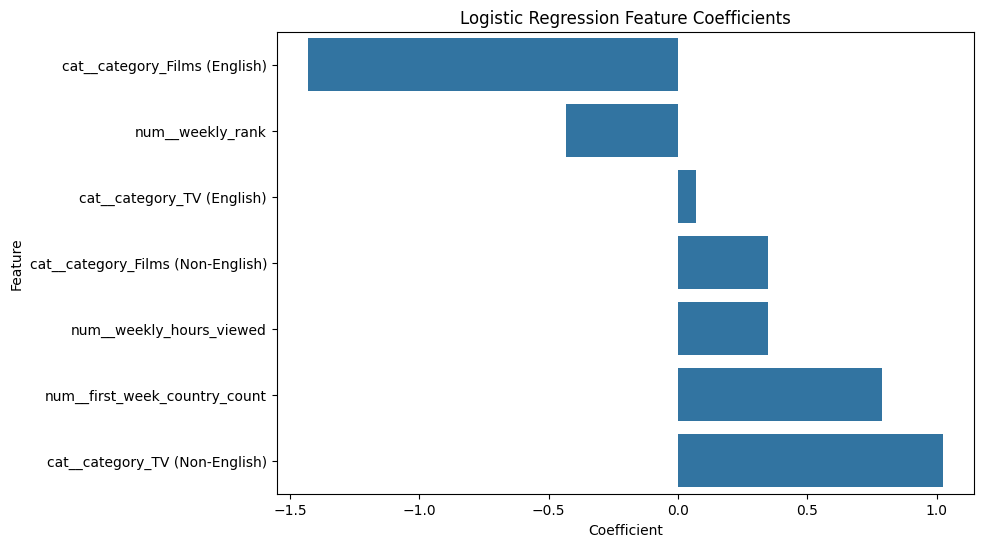

In [644]:
plot_coef_clean = (
    coef_df_clean
    .sort_values("coefficient")
    .copy()
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=plot_coef_clean,
    x="coefficient",
    y="feature"
)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

## 모델 변수 해석

로지스틱 회귀 모델의 계수를 확인한 결과, 장기 흥행 예측에서는 **첫 주 국가 확산 범위(first_week_country_count)**와 **비영어권 TV 콘텐츠**가 장기 흥행 가능성을 높이는 방향으로 나타났다.

반대로 영어 영화 콘텐츠는 장기 흥행과 반대 방향의 계수를 보였다.

또한 첫 주 시청시간은 양의 방향, 첫 진입 순위는 음의 방향으로 나타났다. 넷플릭스 순위는 숫자가 작을수록 높은 순위를 의미하므로, 초기 진입 순위가 높을수록 장기 흥행 가능성이 높아지는 방향으로 해석할 수 있다.

다만 이 결과는 모델이 학습한 관계를 보여주는 것이며, 각 변수가 장기 흥행의 직접적인 원인이라고 단정할 수는 없다.

In [645]:
# clean 모델 기준 예측 확률
y_prob_clean = model_clean.predict_proba(
    X_test_clean
)[:, 1]

# threshold를 0.35로 낮춰서 예측
threshold_clean = 0.35

y_pred_035_clean = (
    y_prob_clean >= threshold_clean
).astype(int)

print(
    "Threshold:",
    threshold_clean
)

print(
    "Accuracy :",
    round(
        accuracy_score(
            y_test_clean,
            y_pred_035_clean
        ),
        3
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test_clean,
            y_pred_035_clean
        ),
        3
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_test_clean,
            y_pred_035_clean
        ),
        3
    )
)

print(
    "F1 Score :",
    round(
        f1_score(
            y_test_clean,
            y_pred_035_clean
        ),
        3
    )
)

Threshold: 0.35
Accuracy : 0.773
Precision: 0.5
Recall   : 0.45
F1 Score : 0.474


## Threshold 0.35 조정 결과

기본 threshold 0.5에서는 Recall이 0.300이었지만, threshold를 0.35로 낮추자 Recall이 0.450으로 상승했다.

반면 Precision은 0.750에서 0.500으로 낮아졌고 Accuracy도 0.818에서 0.773으로 감소했다.

즉 장기 흥행 콘텐츠를 더 많이 찾아내는 대신, 장기 흥행이 아닐 콘텐츠를 장기 흥행으로 잘못 예측하는 경우도 늘어난 것이다.

장기 흥행 후보를 놓치는 비용이 큰 상황이라면 threshold를 낮추는 전략이 유용할 수 있지만, 잘못된 후보를 많이 선별하는 것이 부담되는 상황이라면 기본 threshold를 유지하는 것이 더 적절할 수 있다.

##최종 인사이트
1. TV 콘텐츠는 영화보다 장기 흥행 가능성이 높게 나타났다.
EDA 결과 TV 콘텐츠의 평균 TOP10 유지 기간은 약 3.24주로, 영화의 약 2.23주보다 길었다. 실제 장기 흥행작 상위권에서도 TV 콘텐츠가 많이 포함되어 있었다.

2. 초반 반응이 강한 콘텐츠일수록 오래 흥행하는 경향이 있었다.첫 진입 순위와 장기 흥행 기간은 음의 상관관계(-0.38)를 보였고, 첫 주 시청시간은 양의 상관관계(0.46)를 보였다. 즉 초반 순위가 높고 첫 주 시청시간이 많은 콘텐츠일수록 TOP10에 오래 머무르는 경향이 있었다.

3. 첫 주 글로벌 확산 범위는 장기 흥행 예측에 의미 있는 신호였다.
최종 로지스틱 회귀 모델에서는 첫 주 진입 국가 수가 장기 흥행 가능성을 높이는 방향으로 나타났다. 이는 콘텐츠가 공개 초기에 여러 국가에서 동시에 반응을 얻는 경우 장기 흥행으로 이어질 가능성이 높다는 점을 보여준다.

   **다만 이 결과들은 데이터에서 확인된 관계와 경향이며, 해당 요인들이 장기 흥행을 직접적으로 발생시킨다고 단정할 수는 없다.**

##분석의 한계점
1. 데이터 기간이 약 29주로 제한되어 있다.이번 데이터는 2021년 7월부터 2022년 1월까지의 기간만 포함하고 있다. 따라서 데이터 종료 시점에도 계속 흥행 중이던 콘텐츠는 실제보다 TOP10 유지 기간이 짧게 측정됐을 수 있다.

2. 장르, 제작비, 마케팅 정보가 포함되어 있지 않다.현재 데이터에는 영화/TV와 영어/비영어 구분은 있지만 세부 장르, 제작비, 출연진, 마케팅 규모 같은 정보는 없다. 따라서 장기 흥행의 원인을 더 구체적으로 설명하는 데 한계가 있다.

3. 분석 결과는 인과관계를 의미하지 않는다.첫 주 시청시간, 첫 진입 순위, 첫 주 국가 확산 범위와 장기 흥행 사이의 관계를 확인했지만, 해당 변수들이 직접적으로 장기 흥행을 만들어냈다고 단정할 수는 없다.

4. 장기 흥행 기준인 4주는 분석을 위한 임의의 기준이다.이번 모델에서는 글로벌 TOP10을 4주 이상 유지한 콘텐츠를 장기 흥행작으로 정의했다. 하지만 다른 기준을 적용하면 모델 결과와 해석이 달라질 수 있다.

5. 모델의 Recall이 아직 낮다.기본 threshold 0.5에서 Recall은 0.300으로, 실제 장기 흥행작을 놓치는 경우가 많았다. threshold를 0.35로 낮추면 Recall은 0.450까지 개선되지만 Precision과 Accuracy가 낮아지는 trade-off가 발생했다.

##실제 활용방안
1. 공개 초기 콘텐츠 모니터링
콘텐츠 공개 후 첫 주의 시청시간, 첫 진입 순위, 첫 주 진입 국가 수를 함께 확인하면 장기 흥행 가능성이 높은 콘텐츠를 조기에 선별하는 데 활용할 수 있다.

2. 마케팅 자원 배분
초기 반응이 좋은 콘텐츠는 장기 흥행 후보로 보고 추가 홍보, 추천 노출, 지역별 마케팅 등에 자원을 더 집중하는 판단 근거로 사용할 수 있다.

3. 글로벌 확산 전략
첫 주부터 여러 국가에서 반응을 얻는 콘텐츠가 장기 흥행과 관련된 경향을 보였기 때문에, 지역별 반응을 빠르게 확인하고 자막·더빙·지역 마케팅을 확대하는 전략을 검토할 수 있다.

4. 장기 흥행 후보 관리
기본 threshold 0.5는 잘못된 후보를 줄이는 데 유리하고, threshold 0.35는 장기 흥행 후보를 더 많이 찾아내는 데 유리하다. 따라서 실제 업무에서는 목적에 따라 기준값을 조정해서 사용할 수 있다.

5. 후속 분석 방향
향후 장르, 제작비, 출연진, 공개 시기, 마케팅 규모 같은 추가 데이터를 결합하면 장기 흥행 요인을 더 구체적으로 분석하고 모델 성능도 개선할 수 있다.